# Advanced topics

This notebook covers advanced features of NiSpace:

**Individual-level colocalization** — compute colocalization for each subject separately.  
**Individual-level deviation colocalization** — compute colocalization for each subject separately using z-score maps.  
**Dimensionality reduction** (`reduce_x()`) — summarize a large set of reference maps into a smaller number of components before colocalization.  
**Alternative colocalization methods** — partial correlation, PLS, ridge regression, and more.  

We use the ENIGMA reference datasets (`enigmathick` and `enigmaarea`) as our input maps here — these contain published cortical thickness and surface area effect sizes (Cohen's d) for many psychiatric disorders vs. healthy controls. Note that we're using *reference* data as our input maps, which, in the case of ENIGMA maps, is however often done: it lets us ask questions like "which reference systems explain patterns of grey matter alterations across psychiatric disorders?"

In [1]:
import tqdm.notebook
tqdm.notebook.tqdm = tqdm.tqdm

import numpy as np
import pandas as pd

In [2]:
from nispace.datasets import fetch_reference, fetch_example
from nispace.api import NiSpace

# ENIGMA cortical thickness effect sizes (Cohen's d, cases vs. controls)
# These are reference datasets — we use them as target maps (Y) here
enigma_thick = fetch_reference("enigmathick", parcellation="DesikanKilliany", collection="Adult",
                               print_references=False)
print(f"ENIGMA thickness: {enigma_thick.shape[0]} disorders x {enigma_thick.shape[1]} cortical parcels")
print("Disorders:", list(enigma_thick.index))

# Continuous resting-state network (RSN) reference maps for colocalization
pet_maps = fetch_reference("rsn", parcellation="DesikanKilliany",
                           print_references=False)
print(f"PET: {pet_maps.shape[0]} maps x {pet_maps.shape[1]} parcels")

INFO | 01/06/26 15:07:43 | nispace.datasets: Loading enigmathick maps.


INFO | 01/06/26 15:07:43 | nispace.datasets: Loading integrated collection 'Adult' for dataset 'enigmathick'.


INFO | 01/06/26 15:07:43 | nispace.datasets: Filtering maps by collection.


INFO | 01/06/26 15:07:43 | nispace.datasets: Loading data parcellated with 'DesikanKilliany'


ENIGMA thickness: 17 disorders x 68 cortical parcels
Disorders: [('dx-mdd_age-adult_pub-schmaal2017',), ('dx-adhd_age-allages_pub-hoogman2019',), ('dx-adhd_age-adult_pub-hoogman2019',), ('dx-asd_pub-vanrooij2018',), ('dx-bd_age-adult_pub-hibar2018',), ('dx-scz_pub-vanerp2018',), ('dx-ocd_age-adult_pub-boedhoe2018',), ('dx-epilepsy_pub-whelan2018',), ('dx-epilepsy_subtype-gge_pub-whelan2018',), ('dx-epilepsy_subtype-ltle_pub-whelan2018',), ('dx-epilepsy_subtype-rtle_pub-whelan2018',), ('dx-22q_pub-sun2020',), ('dx-an_pub-walton2022',), ('dx-an_subtype-acAN_pub-walton2022',), ('dx-an_subtype-pwrAN_pub-walton2022',), ('dx-antisocial_pub-gao2024',), ('dx-pd_pub-laansma2021',)]
INFO | 01/06/26 15:07:43 | nispace.datasets: Loading rsn maps.


INFO | 01/06/26 15:07:43 | nispace.datasets: Loading data parcellated with 'DesikanKilliany'


PET: 14 maps x 68 parcels


## Individual-level colocalization

The ENIGMA dataset gives us effect size maps for multiple disorders simultaneously. We can test all disorders at once by passing the full DataFrame as `y`.

In [3]:
nsp = NiSpace(
    x=pet_maps,
    y=enigma_thick,   # all 22 disorder maps as input
    parcellation="DesikanKilliany",
    seed=42,
    n_proc=4
)
nsp.fit()
nsp.colocalize("spearman")
nsp.permute("maps", n_perm=1000)
nsp.correct_p()

colocs = nsp.get_colocalizations()
print(f"Result: {colocs.shape[0]} disorders x {colocs.shape[1]} receptors")
p_values = nsp.get_p_values()
print(f"Result: {p_values.shape[0]} x {p_values.shape[1]} receptors")

INFO | 01/06/26 15:07:43 | nispace.api: *** NiSpace.fit() - Data extraction and preparation. ***


INFO | 01/06/26 15:07:43 | nispace.core.parcellation: Building multi-space Parcellation for 'DesikanKilliany' from library.


INFO | 01/06/26 15:07:43 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR


INFO | 01/06/26 15:07:43 | nispace.core.parcellation: Parcellation 'DesikanKilliany': validation passed.


INFO | 01/06/26 15:07:43 | nispace.api: Checking input data for 'x' (should be, e.g., PET data):


...

Null colocalizations (spearman, 4 proc):   0%|                                                                                                                | 0/1000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc):  76%|████████████████████████████████████████████████████████████████████████████                        | 760/1000 [00:00<00:00, 6356.37it/s]

Null colocalizations (spearman, 4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8190.83it/s]

INFO | 01/06/26 15:07:48 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


Result: 17 disorders x 14 receptors
Result: 1 x 14 receptors


If we plot these data now with the automated method, what was bars before are now scatter points. Each point represents one ENIGMA cortical effect size map, respectively the disorder map's association to each reference map.  
We, by default calculate only one p value for the group-average, which here tests if there is a spatial pattern consistenly associated with ENIGMA maps *across* disorders.

INFO | 01/06/26 15:07:48 | nispace.plotting: Significance annotation: 2/14 p_uncorrected < 0.05, 1/14 p_meffgalwey < 0.05


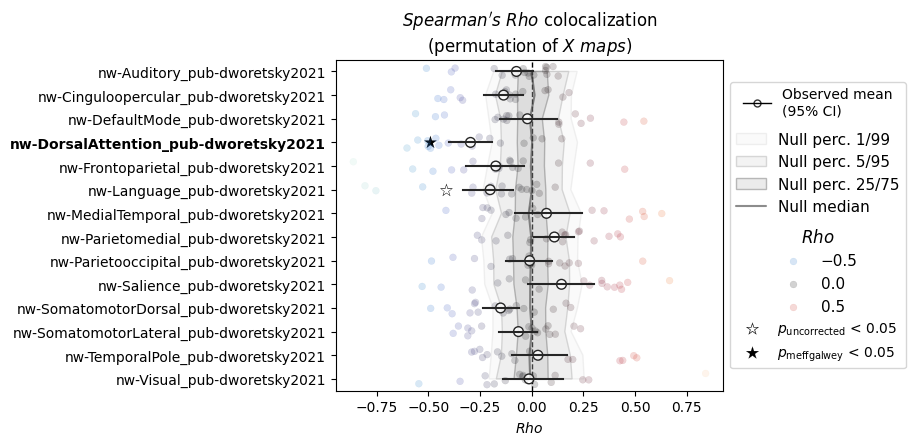

(<Figure size 500x430 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x16addc640>)

In [4]:
# plot all disorders
nsp.plot(sort_by="p")

That is interesting in itself. But we might now want to know how each individual ENIGMA map colocalizes with each individual resting-state network.  

To achieve that, we can set a flag in `NiSpace.permute()`, which deactivates the group-level p value computation.

In [5]:
nsp.colocalize("spearman")
nsp.permute("maps", n_perm=1000, p_from_average_y_coloc=False)
nsp.correct_p()

# both the colocalization and the p value dataframes will now be a n_reference x n_enigma dataframe
colocs = nsp.get_colocalizations()
print(f"Colocalizations: {colocs.shape[0]} disorders x {colocs.shape[1]} receptors")
p_values = nsp.get_p_values()
pc_values = nsp.get_corrected_p_values()
print(f"P-Values: {p_values.shape[0]} disorders x {p_values.shape[1]} receptors")

Colocalizing (spearman, 4 proc):   0%|                                                                                                                          | 0/17 [00:00<?, ?it/s]

Colocalizing (spearman, 4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 1535.42it/s]

INFO | 01/06/26 15:07:48 | nispace.core.permute: Found existing null maps.


INFO | 01/06/26 15:07:48 | nispace.core.permute: Z-standardizing null maps.


Processing null arrays (4 proc):   0%|                                                                                                                        | 0/1000 [00:00<?, ?it/s]

...

Null colocalizations (spearman, 4 proc):   0%|                                                                                                                | 0/1000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc):  76%|████████████████████████████████████████████████████████████████████████████                        | 760/1000 [00:00<00:00, 6486.40it/s]

Null colocalizations (spearman, 4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 8353.24it/s]

INFO | 01/06/26 15:07:49 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


Colocalizations: 17 disorders x 14 receptors
P-Values: 17 disorders x 14 receptors


A heatmap is a typical means to visualize this. For now, we just use `seaborn.heatmap()` and add the p values as annotation.

<Axes: xlabel='map', ylabel='map'>

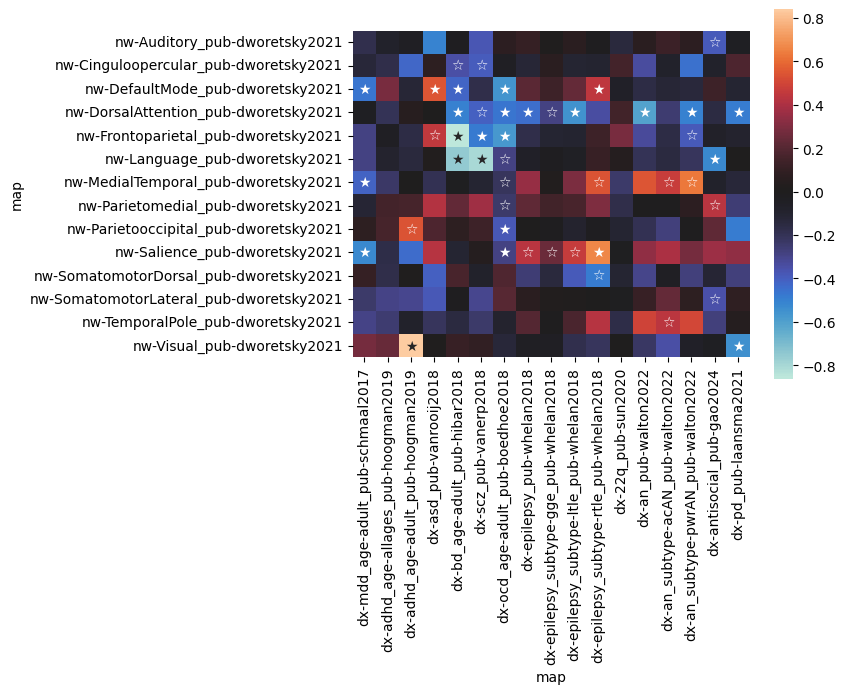

In [6]:
import seaborn as sns

sns.heatmap(
    colocs.T,
    center=0,
    square=True,
    annot=((p_values.T < 0.05).astype(int) + (pc_values.T.astype(int) < 0.05)) \
        .replace({0: "", 1: "☆", 2: "★"}),
    fmt="s"
)

## Individual-level deviation colocalization

Except for the last, the analyses so far have produced group-level results: one colocalization value per disorder or condition. But we often may want to compute colocalization for each subject individually.

The `"zscore(a,b)"` transform in `transform_y()` produces one deviation map per subject in group A (patients). We can then colocalize each map separately and look at the distribution across subjects.

This is particularly useful for stratifying patients by their colocalization profile (e.g., identifying subgroups with different neurotransmitter involvement).

We return to the anorexia nervosa example dataset here — as a reminder, it is **simulated** and not intended for scientific use.

In [7]:
from nispace.datasets import fetch_example

an_data = fetch_example("anorexianervosa", parcellation="Schaefer200")
groups = an_data.index.str.extract(r'(AN|HC)$')[0].values

pet_s200 = fetch_reference("pet", parcellation="Schaefer200",
                           collection="UniqueTracers", print_references=False)

nsp_indiv = NiSpace(
    x=pet_s200,
    y=an_data,
    parcellation="Schaefer200",
    seed=42,
    n_proc=4
)
nsp_indiv.fit()

# compute z-scores: each AN patient mapped relative to HC mean and SD
nsp_indiv.transform_y("zscore(a,b)", groups=groups)

print(f"Individual z-score maps: {nsp_indiv.get_y().shape}")

INFO | 01/06/26 15:07:49 | nispace.datasets: Loading example dataset: 'anorexianervosa', parcellated with: Schaefer200Parcels7Networks.


INFO | 01/06/26 15:07:49 | nispace.datasets: Loading pet maps.


INFO | 01/06/26 15:07:49 | nispace.datasets: Loading integrated collection 'UniqueTracers' for dataset 'pet'.


INFO | 01/06/26 15:07:49 | nispace.datasets: Filtering maps by collection.


INFO | 01/06/26 15:07:49 | nispace.datasets: Loading data parcellated with 'Schaefer200Parcels7Networks'


...

INFO | 01/06/26 15:07:49 | nispace.core.parcellation: Parcellation 'Schaefer200Parcels7Networks': validation passed.


INFO | 01/06/26 15:07:49 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


WARNING | 01/06/26 15:07:49 | nispace.io: Parcellated data contains nan values!


INFO | 01/06/26 15:07:49 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


Individual z-score maps: (50, 200)


In [8]:
# colocalize each subject's z-score map with PET maps
nsp_indiv.colocalize("spearman")

# result: one row per AN subject, one column per receptor
indiv_colocs = nsp_indiv.get_colocalizations()
print(f"Individual colocalizations: {indiv_colocs.shape}")
indiv_colocs.head(5)

Colocalizing (spearman, 4 proc):   0%|                                                                                                                          | 0/50 [00:00<?, ?it/s]

Colocalizing (spearman, 4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 50/50 [00:00<00:00, 2738.83it/s]

Individual colocalizations: (50, 29)


set                                                      General  \
map       target-CMRglu_tracer-fdg_n-20_dx-hc_pub-castrillon2023   
sub-001AN                                           0.017047       
sub-002AN                                           0.050685       
sub-003AN                                           0.049166       
sub-004AN                                          -0.063293       
sub-005AN                                          -0.048554       

set                                                            \
map       target-rCPS_tracer-leucine_n-42_dx-hc_pub-smith2023   
sub-001AN                                           0.063481    
sub-002AN                                           0.028544    
sub-003AN                                           0.004716    
sub-004AN                                          -0.073066    
sub-005AN                                          -0.017159    

set                                                           \
map       target-SV2A_tracer-ucbj_n-76_dx-hc_pub-finnema2016   
sub-001AN                                           0.077512   
sub-002AN                                           0.049336   
sub-003AN                                          -0.015789   
sub-004AN                                          -0.114253   
sub-005AN                                          -0.094473   

set                                                             \
map       target-HDAC_tracer-martinostat_n-8_dx-hc_pub-wey2016   
sub-001AN                                           0.022713     
sub-002AN                                           0.059077     
sub-003AN                                           0.042196     
sub-004AN                                          -0.047778     
sub-005AN                                          -0.034040     

set                                                           \
map       target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020   
sub-001AN                                           0.000522   
sub-002AN                                           0.010109   
sub-003AN                                          -0.058407   
sub-004AN                                          -0.121368   
sub-005AN                                          -0.040044   

set                                              Immunity  \
map       target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018   
sub-001AN                                       -0.051870   
sub-002AN                                        0.077949   
sub-003AN                                       -0.095477   
sub-004AN                                       -0.006215   
sub-005AN                                       -0.007892   

set                                                       \
map       target-COX1_tracer-ps13_n-11_dx-hc_pub-kim2020   
sub-001AN                                       0.031316   
sub-002AN                                      -0.063088   
sub-003AN                                       0.023831   
sub-004AN                                      -0.059130   
sub-005AN                                      -0.018086   

set                                                  Glutamate  \
map       target-mGluR5_tracer-abp688_n-73_dx-hc_pub-smart2019   
sub-001AN                                           0.148510     
sub-002AN                                           0.063228     
sub-003AN                                           0.051145     
sub-004AN                                          -0.078576     
sub-005AN                                          -0.036658     

set                                                            \
map       target-NMDA_tracer-ge179_n-29_dx-hc_pub-galovic2021   
sub-001AN                                           0.033367    
sub-002AN                                           0.019509    
sub-003AN                                          -0.006990    
sub-004AN                                          -0.080251    
sub-

In [9]:
# for permutation testing with individual maps, we permute group labels
# p values are computed for the MEAN colocalization across subjects by default
#  -> compare to the section above
nsp_indiv.permute("groups", groups=groups, n_perm=1000)
nsp_indiv.correct_p()
p_indiv = nsp_indiv.get_p_values()

print(f"P-values shape: {p_indiv.shape}")
print(p_indiv.T.sort_values(by=p_indiv.index[0]).head(10))

INFO | 01/06/26 15:07:49 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


Permuting groups (4 proc):   0%|                                                                                                                              | 0/1000 [00:00<?, ?it/s]

Permuting groups (4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 868745.65it/s]

Null transformations (spearman, 4 proc):   0%|                                                                                                                | 0/1000 [00:00<?, ?it/s]

Null transformations (spearman, 4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 14698.29it/s]

...

Null colocalizations (spearman, 4 proc):  76%|████████████████████████████████████████████████████████████████████████████▊                        | 760/1000 [00:00<00:00, 848.87it/s]

Null colocalizations (spearman, 4 proc):  89%|█████████████████████████████████████████████████████████████████████████████████████████▋           | 888/1000 [00:01<00:00, 814.16it/s]

Null colocalizations (spearman, 4 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:01<00:00, 972.59it/s]

INFO | 01/06/26 15:07:51 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


P-values shape: (1, 29)
                                                                              mean
set                      map                                                      
Serotonin                target-5HTT_tracer-dasb_n-18_dx-hc_pub-savli2012    0.001
                         target-5HT1a_tracer-way100635_n-35_dx-hc_pub-sa...  0.001
GABA                     target-GABAa5_tracer-ro154513_n-10_dx-hc_pub-lu...  0.001
Dopamine                 target-FDOPA_tracer-fluorodopa_n-12_dx-hc_pub-g...  0.001
General                  target-VMAT2_tracer-dtbz_n-76_dx-hc_pub-larsen2020  0.002
Dopamine                 target-D1_tracer-sch23390_n-13_dx-hc_pub-kaller...  0.002
Opioids/Endocannabinoids target-MOR_tracer-carfentanil_n-204_dx-hc_pub-k...  0.008
Immunity                 target-TSPO_tracer-pbr28_n-6_dx-hc_pub-lois2018     0.012
Dopamine                 target-D23_tracer-flb457_n-55_dx-hc_pub-sandieg...  0.012
Opioids/Endocannabinoids target-CB1_tracer-omar_n-77_dx-hc_pub-

INFO | 01/06/26 15:07:52 | nispace.plotting: Significance annotation: 12/29 p_uncorrected < 0.05, 6/29 p_meffgalwey < 0.05


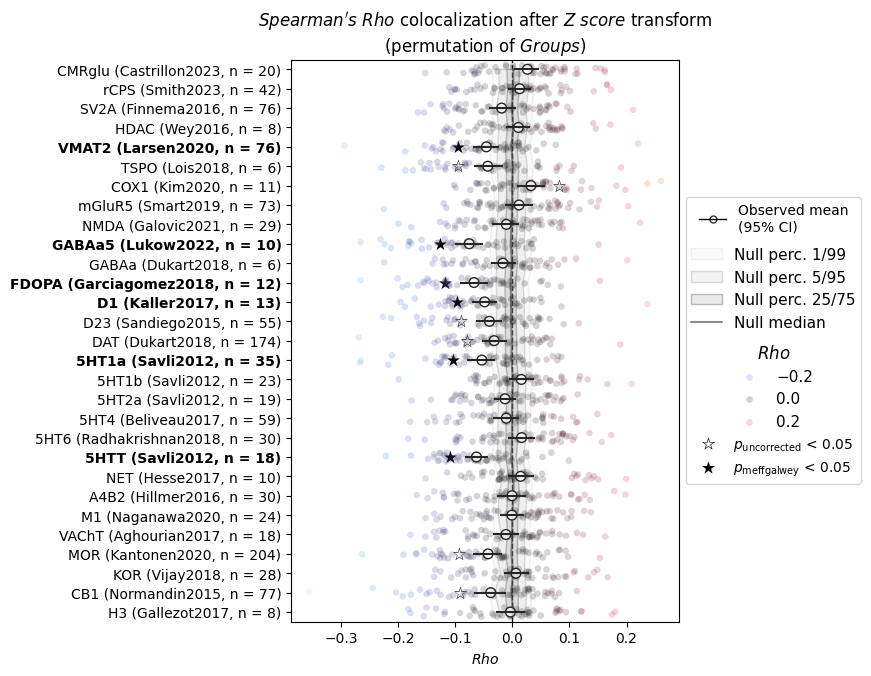

(<Figure size 500x730 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization after $Z\\ score$ transform\n(permutation of $Groups$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x16c59ac10>)

In [10]:
# plot
nsp_indiv.plot()

## Dimensionality reduction with `reduce_x()`

When you have many reference maps (30 PET tracers, thousands of genes), interpreting individual colocalizations can be difficult — and many maps are correlated with each other. `reduce_x()` summarizes the reference maps into a smaller set of components using PCA, ICA, or factor analysis.

After reduction, `colocalize()` operates on the components instead of individual maps.

In [11]:
# reduce the PET maps to their principal components
nsp.reduce_x("pca", n_components=5)  # keep 5 components

# colocalize on the reduced space
nsp.colocalize("spearman", X_reduction="pca")
nsp.permute("maps", n_perm=1000, X_reduction="pca")

pca_colocs = nsp.get_colocalizations(X_reduction="pca")
print(f"PCA colocalizations: {pca_colocs.shape[0]} disorders x {pca_colocs.shape[1]} components")
pca_colocs

INFO | 01/06/26 15:07:52 | nispace.core.reduce_x: Performing dimensionality reduction using pca (max components: 5, min EV: None).


INFO | 01/06/26 15:07:52 | nispace.core.reduce_x: Returning 5 principal component(s).


Colocalizing (spearman, 4 proc):   0%|                                                                                                                          | 0/17 [00:00<?, ?it/s]

Colocalizing (spearman, 4 proc): 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 1594.72it/s]

INFO | 01/06/26 15:07:52 | nispace.core.permute: Found existing null maps.


...

Null colocalizations (spearman, 4 proc):   0%|                                                                                                                | 0/1000 [00:00<?, ?it/s]

Null colocalizations (spearman, 4 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:00<00:00, 11323.65it/s]

INFO | 01/06/26 15:07:52 | nispace.core.permute: Calculating exact p-values (tails = {'rho': 'two'}).


PCA colocalizations: 17 disorders x 5 components


,c0,c1,c2,c3,c4
map,,,,,
dx-mdd_age-adult_pub-schmaal2017,0.350335,-0.381529,-0.178854,-0.356347,-0.011331
dx-adhd_age-allages_pub-hoogman2019,-0.132182,-0.057538,0.045820,-0.319895,0.396888
dx-adhd_age-adult_pub-hoogman2019,-0.014370,-0.526697,-0.062857,-0.445011,0.198560
dx-asd_pub-vanrooij2018,-0.310917,0.311928,0.475533,-0.249393,0.087193
dx-bd_age-adult_pub-hibar2018,0.180692,-0.700799,0.065560,0.539223,0.002533
dx-scz_pub-vanerp2018,-0.054100,-0.472228,0.179924,0.260594,-0.159836
dx-ocd_age-adult_pub-boedhoe2018,0.471912,-0.214527,-0.215989,0.270299,0.046994
dx-epilepsy_pub-whelan2018,-0.191002,0.080550,0.122663,0.522908,0.284856
dx-epilepsy_subtype-gge_pub-whelan2018,-0.044712,0.110665,0.224301,0.256793,0.414935


INFO | 01/06/26 15:07:53 | nispace.plotting: Significance annotation: 1/5 p_uncorrected < 0.05, 0/5 p_meffgalwey < 0.05 (no correction applied)


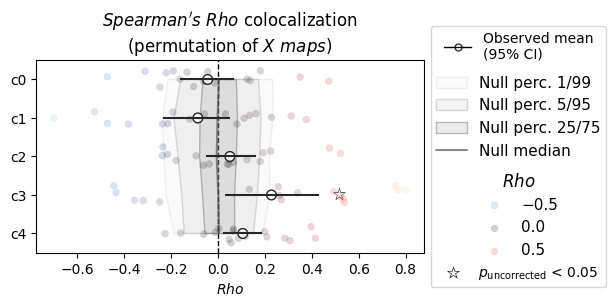

(<Figure size 500x250 with 1 Axes>,
 <Axes: title={'center': "$Spearman's\\ Rho$ colocalization\n(permutation of $X\\ maps$)"}, xlabel='$Rho$'>,
 <seaborn._core.plot.Plotter at 0x16e177e80>)

In [12]:
nsp.plot(X_reduction="pca")

## Alternative colocalization methods

Spearman correlation is the default, but NiSpace supports several other methods. Each has different assumptions and use cases.  

Importantly, methods might return multiple different colocalization metrics. For example, a linear regression model (`"mlr"`) already returns both beta coefficients (one for each X map, as for correlations) **and** the R^2 value (one across X maps). Each of these colocalization statistics will furthermore have an associated p values after `.permute()` has been run.

In [13]:
# set up a simple analysis for comparison
nsp_methods = NiSpace(
    x=pet_maps,
    y=enigma_thick.loc[["dx-bd_age-adult_pub-hibar2018"]],  # just bipolar disorder for clarity
    parcellation="DesikanKilliany",
    seed=42
)
nsp_methods.fit()

# Pearson correlation
nsp_methods.colocalize("pearson")
pearson = nsp_methods.get_colocalizations()
print("Pearson:", pearson.values.squeeze())
print("")

# Multiple linear regression (MLR)
nsp_methods.colocalize("mlr")
mlr = nsp_methods.get_colocalizations()
print("MLR beta:", mlr["beta"].values.squeeze())
print("MLR R2:", mlr["r2"].values.squeeze())
print("")

# Partial least squares (PLS)
nsp_methods.colocalize("pls", n_components=3)
pls = nsp_methods.get_colocalizations()
print("PLS beta:", pls["beta"].values.squeeze())
print("PLS R2:", pls["r2"].values.squeeze())
print("")

# Dominance analysis (takes the longest)
nsp_methods.colocalize("dominance")
dom = nsp_methods.get_colocalizations()
print("Dominance: sum (matches MLR R2) :", dom["sum"].values.squeeze())
print("Dominance: total (sum of total is MLR R2):", dom["total"].values.squeeze())
print("Dominance: individual (like a leave-one-out MLR R2):", dom["individual"].values.squeeze())
print("Dominance: relative (fraction of sum R2):", dom["relative"].values.squeeze())


INFO | 01/06/26 15:07:53 | nispace.core.parcellation: Building multi-space Parcellation for 'DesikanKilliany' from library.


INFO | 01/06/26 15:07:53 | nispace.core.parcellation: Available spaces: MNI152NLin2009cAsym, MNI152NLin6Asym, fsaverage, fsLR


INFO | 01/06/26 15:07:53 | nispace.core.parcellation: Parcellation 'DesikanKilliany': validation passed.


INFO | 01/06/26 15:07:53 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


INFO | 01/06/26 15:07:53 | nispace.io: Input type: DataFrame, assuming parcellated data with shape (n_files/subjects/etc, n_parcels).


...

PLS beta: [ 0.0021201  -0.01162152 -0.01987142 -0.01660991 -0.024217   -0.00883197
  0.01095411  0.00524392  0.0065681   0.02115439  0.00681146  0.00787176
  0.00419393  0.01316884]
PLS R2: 0.5715146



Colocalizing (dominance, 1 proc):   0%|                                                                                                                          | 0/1 [00:00<?, ?it/s]

Colocalizing (dominance, 1 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.71it/s]

Colocalizing (dominance, 1 proc): 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  3.70it/s]

Dominance: sum (matches MLR R2) : 0.46437818
Dominance: total (sum of total is MLR R2): [1.3349009e-04 8.5304175e-03 5.7703033e-02 3.6930375e-02 1.8202354e-01
 5.0407633e-02 2.7346514e-02 8.9180330e-04 1.0367648e-02 4.3500487e-02
 4.6723862e-03 1.7571739e-03 2.8868834e-04 3.9825007e-02]
Dominance: individual (like a leave-one-out MLR R2): [-0.00627205 -0.00057247  0.08408586  0.03669057  0.35684335  0.12443971
  0.05019241 -0.00470505  0.02745323  0.01524752  0.00595633  0.00311236
 -0.0021382   0.07029137]
Dominance: relative (fraction of sum R2): [2.87459872e-04 1.83695480e-02 1.24258704e-01 7.95264989e-02
 3.91972631e-01 1.08548664e-01 5.88884540e-02 1.92042463e-03
 2.23258715e-02 9.36746970e-02 1.00615975e-02 3.78392870e-03
 6.21666433e-04 8.57598558e-02]


If we plot multi-outcome colocalization results, we will automatically get one plot for each metric. E.g., for the quite detailled dominance output:

INFO | 01/06/26 15:07:53 | nispace.core.parcellation: Lazy-loading parcellation image for space 'fsLR'.


INFO | 01/06/26 15:07:53 | nispace.core.permute: No null maps found.


INFO | 01/06/26 15:07:53 | nispace.core.permute: Generating null maps (n = 1000, null_method = 'alexander_bloch').


INFO | 01/06/26 15:07:53 | nispace.nulls: Null map generation: Assuming n = 14 data vector(s) for n = 68 parcels.


INFO | 01/06/26 15:07:53 | nispace.nulls: Using provided precomputed spin matrix.


...

Null colocalizations (dominance, 4 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████▌| 996/1000 [01:03<00:00, 15.88it/s]

Null colocalizations (dominance, 4 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:03<00:00, 15.87it/s]

Null colocalizations (dominance, 4 proc): 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [01:03<00:00, 15.80it/s]

INFO | 01/06/26 15:08:57 | nispace.core.permute: Calculating exact p-values (tails = {'sum': 'upper', 'total': 'upper', 'individual': 'upper', 'relative': 'upper'}).


INFO | 01/06/26 15:08:57 | nispace.plotting: Significance annotation: 0/1 p_uncorrected < 0.05, 0/1 p_meffgalwey < 0.05


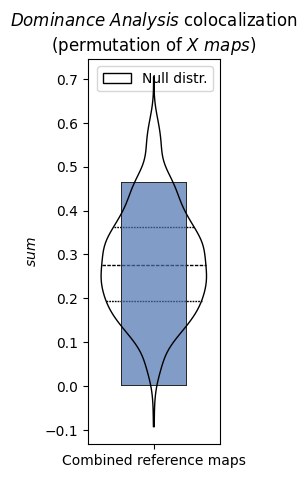

INFO | 01/06/26 15:08:57 | nispace.plotting: Significance annotation: 1/14 p_uncorrected < 0.05, 1/14 p_meffgalwey < 0.05


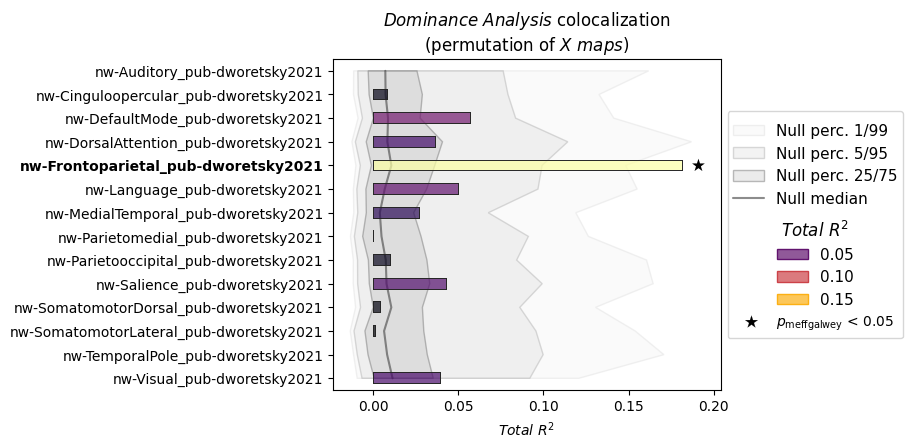

INFO | 01/06/26 15:08:57 | nispace.plotting: Significance annotation: 2/14 p_uncorrected < 0.05, 1/14 p_meffgalwey < 0.05


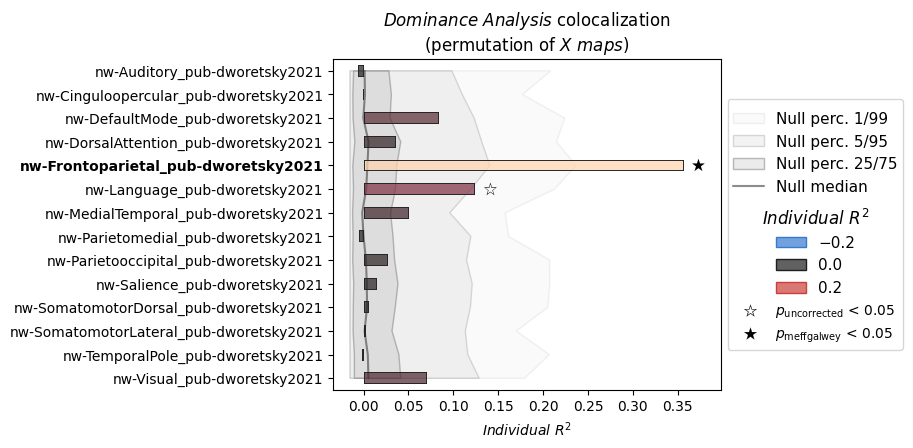

INFO | 01/06/26 15:08:58 | nispace.plotting: Significance annotation: 0/14 p_uncorrected < 0.05, 0/14 p_meffgalwey < 0.05


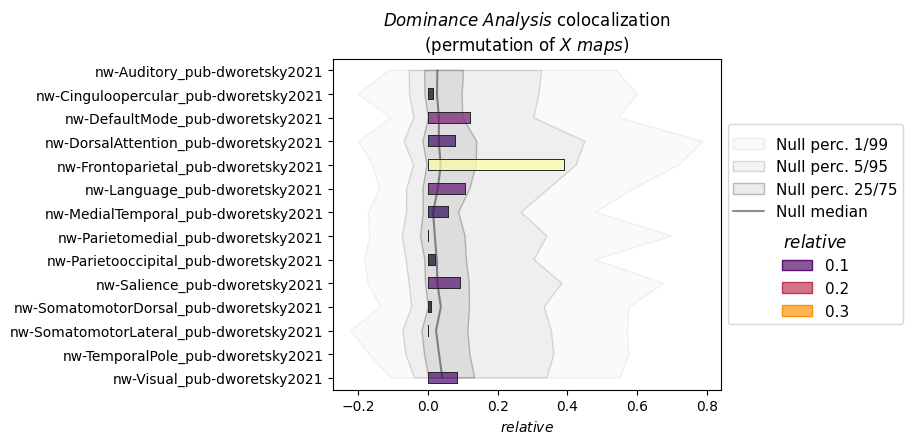

{'sum': (<Figure size 170x500 with 1 Axes>,
  <Axes: title={'center': '$Dominance\\ Analysis$ colocalization\n(permutation of $X\\ maps$)'}, ylabel='$sum$'>,
  <seaborn._core.plot.Plotter at 0x168af05b0>),
 'total': (<Figure size 500x430 with 1 Axes>,
  <Axes: title={'center': '$Dominance\\ Analysis$ colocalization\n(permutation of $X\\ maps$)'}, xlabel='$Total\\ R^2$'>,
  <seaborn._core.plot.Plotter at 0x17acf1940>),
 'individual': (<Figure size 500x430 with 1 Axes>,
  <Axes: title={'center': '$Dominance\\ Analysis$ colocalization\n(permutation of $X\\ maps$)'}, xlabel='$Individual\\ R^2$'>,
  <seaborn._core.plot.Plotter at 0x17ae17d90>),
 'relative': (<Figure size 500x430 with 1 Axes>,
  <Axes: title={'center': '$Dominance\\ Analysis$ colocalization\n(permutation of $X\\ maps$)'}, xlabel='$relative$'>,
  <seaborn._core.plot.Plotter at 0x17b074c40>)}

In [14]:
# first: run the proper permutation; will take some time for dominance analysis
nsp_methods.permute("maps", n_perm=1000, n_proc=4)
nsp_methods.correct_p()

# show
nsp_methods.plot()

## Summary

| Feature | How to use |
|---------|------------|
| Individual-level colocalization | `nsp.colocalize()` + `nsp.permute(pooled_p=False)` |
| Individual-level deviation colocalization | `nsp.transform_y("zscore(a,b)", groups=...)` + `nsp.colocalize()` + `nsp.permute("groups")` |
| Dimensionality reduction | `nsp.reduce_x("pca", n_components=5)`, then `nsp.colocalize(..., X_reduction="pca")` |
| Alternative colocalization methods | `nsp.colocalize("partialpearson")`, `"pls"`, `"ridge"`, etc. |

This is the last notebook in the introduction series. For more, see the [API reference](../api_ref.rst) and the [Example notebooks](../examples.rst).